# Model pipeline - Regression  

This notebook fits and evaluates an XGBoost regressor for predicting the magnitude of biodiversity anomalies based on weather features  

Note: Time series data - cannot use random train-test split (that would leak future information)

---
### Load packages and data

In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor

from sklearn import set_config
set_config(transform_output='pandas')

In [42]:
full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

Select only necessary columns 

In [43]:
df = full_df[['state', 'year_offset', 'month_sin', 'month_cos',
              'n_hot_days', 'n_hot_days_lag1', 'n_hot_days_roll3', 
              'heavy_rain_days', 'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
              'temp_anom_z', 'temp_anom_z_lag1', 'temp_anom_z_roll3',
              'precip_anom_z', 'precip_anom_z_lag1', 'precip_anom_z_roll3',
              'drought_index', 'drought_index_lag1', 'drought_index_roll3',
              'log_n_obs', 'turnover_residual_z']].copy()        

df = df.rename(columns={'turnover_residual_z': 'biodiversity_z'})

In [44]:
df.sample(10)

,state,year_offset,month_sin,month_cos,n_hot_days,n_hot_days_lag1,n_hot_days_roll3,heavy_rain_days,heavy_rain_days_lag1,heavy_rain_days_roll3,...,temp_anom_z_lag1,temp_anom_z_roll3,precip_anom_z,precip_anom_z_lag1,precip_anom_z_roll3,drought_index,drought_index_lag1,drought_index_roll3,log_n_obs,biodiversity_z
1106,Bremen,15,-5.000000e-01,-8.660254e-01,4,2.0,0.666667,0,0.0,0.000000,...,2.105783,0.475308,-1.284162,-0.847052,-0.626419,1.661595,2.952835,1.101727,2.170262,1.703490
1871,Mecklenburg-Vorpommern,20,1.000000e+00,6.123234e-17,0,0.0,0.000000,0,2.0,2.666667,...,1.674314,0.685040,-0.940826,1.619727,1.374909,2.187373,0.054587,-0.689869,3.959900,1.403258
3423,Schleswig-Holstein,14,-5.000000e-01,-8.660254e-01,4,0.0,0.000000,0,0.0,1.333333,...,1.181737,1.520660,-2.148792,-1.292852,-0.588842,3.496636,2.474589,2.109502,3.833083,-1.349478
1338,Hamburg,17,1.224647e-16,-1.000000e+00,2,0.0,0.000000,2,1.0,2.000000,...,-1.347667,-0.916250,-0.253975,1.795136,0.756490,1.803826,-3.142803,-1.672740,3.353339,0.321700
268,Bayern,1,-8.660254e-01,-5.000000e-01,0,2.0,0.666667,5,4.0,1.666667,...,-0.521238,-0.247563,1.166032,0.740343,-0.232190,-2.548929,-1.261581,-0.015373,2.888741,-0.052057
3449,Schleswig-Holstein,16,-1.000000e+00,-1.836970e-16,0,2.0,0.666667,0,2.0,2.000000,...,2.035368,0.513757,-0.891848,-0.235916,0.068881,0.778572,2.271284,0.444876,3.804548,1.513486
2065,Niedersachsen,15,5.000000e-01,-8.660254e-01,0,0.0,0.000000,1,0.0,1.333333,...,0.277270,0.678957,-0.225086,-0.451516,-0.056847,-0.898679,0.728786,0.735804,4.685016,0.462722
882,Brandenburg,12,-2.449294e-16,1.000000e+00,0,0.0,0.666667,1,0.0,0.666667,...,-1.766223,-0.211991,-0.587768,-0.484119,-0.317012,0.626293,-1.282104,0.105021,2.859739,-0.094197
2851,Sachsen,4,-1.000000e+00,-1.836970e-16,0,0.0,0.000000,1,2.0,1.333333,...,-0.432693,-0.282879,-0.350128,0.456888,-0.163698,-0.996928,-0.889581,-0.119181,2.411620,1.151949
1856,Mecklenburg-Vorpommern,18,-2.449294e-16,1.000000e+00,0,0.0,0.000000,1,0.0,0.333333,...,0.320561,0.209149,1.140909,-1.155549,-0.459155,-1.763973,1.476110,0.668304,3.291813,0.910543


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3716 entries, 0 to 3715
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   state                  3716 non-null   object 
 1   year_offset            3716 non-null   int32  
 2   month_sin              3716 non-null   float64
 3   month_cos              3716 non-null   float64
 4   n_hot_days             3716 non-null   int64  
 5   n_hot_days_lag1        3716 non-null   float64
 6   n_hot_days_roll3       3716 non-null   float64
 7   heavy_rain_days        3716 non-null   int64  
 8   heavy_rain_days_lag1   3716 non-null   float64
 9   heavy_rain_days_roll3  3716 non-null   float64
 10  temp_anom_z            3716 non-null   float32
 11  temp_anom_z_lag1       3716 non-null   float32
 12  temp_anom_z_roll3      3716 non-null   float64
 13  precip_anom_z          3716 non-null   float32
 14  precip_anom_z_lag1     3716 non-null   float32
 15  prec

---
### Define X and y and create train-test splits  

Note that due to time-series data, random train-test split is not appropriate. Instead, split data based on year so that there is no leakage from future data in training.  

Use rolling/walk-forward/expanding-window validation within training set for more robust validation.

In [46]:
df.value_counts('year_offset')

year_offset
15    192
19    192
20    192
18    192
17    192
16    192
12    191
14    190
9     189
13    189
10    189
11    188
8     186
7     182
6     181
5     178
4     154
3     144
2     143
0     133
1     127
Name: count, dtype: int64

In [47]:
train_val = df.loc[df['year_offset']<17]
test = df.loc[df['year_offset']>=17]

Create X_test and y_test

In [48]:
X_test = test.copy()
y_test = X_test.pop('biodiversity_z')

For X_train and y_train when using walk-forward validation with expanding window, need to define these within a loop and fit the pipeline (defined below) to each iteration.  

---
### Baseline model

Predict average biodiversity z score for everything

In [49]:
X_trainval = train_val.copy()
y_trainval = X_trainval.pop('biodiversity_z')

In [50]:
# Dummy model
dummy_model = DummyRegressor()
dummy_model.fit(X_trainval, y_trainval)
dummy_train_pred = dummy_model.predict(X_trainval)

In [51]:
# Defining function for computing many scores at once
def score_model(model_name, y_true, y_pred):
  scores = {
      'Model': model_name,
      'MAE ($)': round(mean_absolute_error(y_true, y_pred), 2),
      'RMSE ($)': round(root_mean_squared_error(y_true, y_pred), 2),
      'MAPE (%)': round(100 * mean_absolute_percentage_error(y_true, y_pred), 2),
      'R-Squared': round(r2_score(y_true, y_pred), 3)
  }
  return scores

# Setting up list for score comparisons
model_scores = []

In [52]:
model_scores.append(score_model('Baseline Model Train', y_trainval, dummy_train_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.0


Let's see how it does on the test set

In [53]:
dummy_test_pred = dummy_model.predict(X_test)

model_scores.append(score_model('Baseline Model Test', y_test, dummy_test_pred))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105


Let's try a heuristic model, with biodiversity score decreasing as number of hot days increases

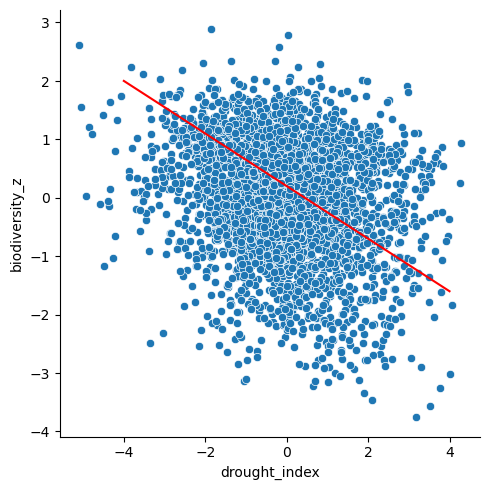

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

train_data = X_trainval.copy()
train_data['biodiversity_z'] = y_trainval

sns.relplot(data = train_data,
            kind='scatter',
            x='drought_index',
            y='biodiversity_z')
plt.plot([-4, 4], [2, -1.6], 'r-')
plt.show();

Let's try biodiversity_z decreasing by 0.2 for every increase in drought_index (-1.6/8)

In [55]:
intuition_pred_train = -0.2*train_data['drought_index']
model_scores.append(score_model('Heuristic Model Train', y_trainval, intuition_pred_train))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.79,0.99,193.75,0.037


In [57]:
intuition_pred_test = -0.2*X_test['drought_index']
model_scores.append(score_model('Heuristic Model Test', y_test, intuition_pred_test))
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.79,0.99,193.75,0.037
3,Heuristic Model Test,0.68,0.83,190.62,-0.143


The heuristic model performs worse than the dummy model. Let's see if we can do better with a Regression model.

---
### Create pipeline

Define branches for numeric and categorical preprocessing for each model in model selection step (below)

Distance-based models (e.g. KNN) needs scaled features but Tree-based models don't

In [58]:
cat_features = ['state']
cyc_features = ['month_sin', 'month_cos']
num_features = [col for col in X_test.columns if (col not in (cat_features + cyc_features))]

In [59]:
# Build categorical pipeline (with one-hot-encoding for state)
oh_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Create preprocessor for model (xgboost doesn't need scaled features)

In [60]:
preprocessor_noscale = ColumnTransformer(
    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features),
        ('cyc', 'passthrough', cyc_features)
    ]
)

preprocessor_noscale

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Build full pipeline:  

In [61]:
# XGBoost
full_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor_noscale),
    ('model', XGBRegressor())
])


---
Model selection and fine tuning

define model & grid

In [ ]:
# models = {
#     'XGBoost': {
#         'pipeline': full_pipeline_xgb,
#         'param_grid': {
#             'model__n_estimators': [100, 300, 500],
#             'model__max_depth': [3, 5, 7],
#             "model__min_child_weight": [1, 3, 5],
#             'model__learning_rate': [0.01, 0.05, 0.1],
#             'model__subsample': [0.7, 1.0],
#             'model__colsample_bytree': [0.7, 1.0]
#         }
#     }
# }

---
Use manual time-aware train-val split

In [62]:
# Helper function for expanding splits
def get_expanding_splits(years, min_train_years=5):
    splits = []
    
    for i in range(min_train_years, len(years)):
        train_years = years[:i]
        val_year = years[i]
        splits.append((train_years, val_year))
    
    return splits

Apply function

Let's try using Bayesian optimisation (Optuna), which intelligently searches the space instead of trying everything, with early stopping.  

Note: Early stopping only works for some models (in this case, only XGBoost, not KNN or RF)

In [63]:
import optuna
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import mean_squared_error

def optuna_rolling_search_regression(
    df,
    features,
    target,
    pipeline,
    param_space_fn,
    min_train_years=10,
    n_trials=50,
    use_early_stopping=False,
    early_stopping_rounds=50
):
    """
    Rolling CV Optuna search for regression models (e.g. XGBoost Regressor)
    """

    # 1️⃣ Prepare rolling splits
    years = sorted(df['year_offset'].unique())
    splits = get_expanding_splits(years, min_train_years)

    def objective(trial):
        # 2️⃣ Sample hyperparameters
        params = param_space_fn(trial)

        fold_scores = []

        for train_years, val_year in splits:
            train = df[df['year_offset'].isin(train_years)]
            val   = df[df['year_offset'] == val_year]

            X_train, y_train = train[features], train[target]
            X_val, y_val     = val[features], val[target]

            # 3️⃣ Clone pipeline
            pipe = clone(pipeline)
            pipe.set_params(**params)

            # 4️⃣ Early stopping (only works if final model supports it)
            fit_params = {}
            if use_early_stopping:
                fit_params = {
                    'model__eval_set': [(X_val, y_val)],
                    'model__early_stopping_rounds': early_stopping_rounds,
                    'model__verbose': False
                }

            pipe.fit(X_train, y_train, **fit_params)

            # 5️⃣ Predict (REGRESSION)
            y_pred = pipe.predict(X_val)

            # 6️⃣ Metric (RMSE)
            rmse = root_mean_squared_error(y_val, y_pred)
            fold_scores.append(rmse)

        # 7️⃣ Return mean score across folds
        return np.mean(fold_scores)

    # 8️⃣ Run study (minimize RMSE)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    # 9️⃣ Collect results
    results = []
    for trial in study.trials:
        results.append({
            'params': trial.params,
            'rmse': trial.value,
        })

    results_df = pd.DataFrame(results).sort_values('rmse')

    return study, results_df

c:\Users\Darach\miniconda3\envs\wildsignal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [64]:
def xgb_param_space(trial):
    return {
        # 🌳 Tree structure
        "model__max_depth": trial.suggest_int("max_depth", 3, 10),
        "model__min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        # 🎯 Learning
        "model__learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "model__n_estimators": trial.suggest_int("n_estimators", 200, 1500),

        # 🌲 Sampling
        "model__subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        # ⚖️ Regularization
        "model__gamma": trial.suggest_float("gamma", 0, 5),
        "model__reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "model__reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
    }


In [86]:
features = cat_features + cyc_features + num_features

study, results_df = optuna_rolling_search_regression(
    df=train_val,
    features=features,
    target='biodiversity_z',
    pipeline=full_pipeline_xgb,
    param_space_fn=xgb_param_space,
    n_trials=50,
    use_early_stopping=False
)

[I 2026-04-20 00:15:35,595] A new study created in memory with name: no-name-9ecafb43-a5de-4bae-a6d9-b409e09f3dad
[I 2026-04-20 00:15:45,830] Trial 0 finished with value: 1.0039240702632406 and parameters: {'max_depth': 9, 'min_child_weight': 4, 'learning_rate': 0.00130637301372152, 'n_estimators': 769, 'subsample': 0.9756394939841002, 'colsample_bytree': 0.9200973251404851, 'gamma': 4.501258112513565, 'reg_alpha': 3.2156485005235455e-06, 'reg_lambda': 1.0796417176143225e-06}. Best is trial 0 with value: 1.0039240702632406.
[I 2026-04-20 00:15:52,536] Trial 1 finished with value: 1.0186271680352732 and parameters: {'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.03447926094062101, 'n_estimators': 814, 'subsample': 0.6233929172510383, 'colsample_bytree': 0.814881677099302, 'gamma': 0.27310737885683, 'reg_alpha': 9.947471515811908e-08, 'reg_lambda': 4.956302937493659e-05}. Best is trial 0 with value: 1.0039240702632406.
[I 2026-04-20 00:15:55,795] Trial 2 finished with value: 1

In [87]:
# Sort by F1
results_df.sort_values('rmse', ascending=True).head(10)

,params,rmse
35,"{'max_depth': 7, 'min_child_weight': 9, 'learn...",0.995243
41,"{'max_depth': 7, 'min_child_weight': 9, 'learn...",0.995253
34,"{'max_depth': 7, 'min_child_weight': 10, 'lear...",0.995832
23,"{'max_depth': 7, 'min_child_weight': 8, 'learn...",0.996499
36,"{'max_depth': 6, 'min_child_weight': 9, 'learn...",0.997104
42,"{'max_depth': 7, 'min_child_weight': 9, 'learn...",0.997849
27,"{'max_depth': 7, 'min_child_weight': 9, 'learn...",0.998090
37,"{'max_depth': 6, 'min_child_weight': 8, 'learn...",0.998573
11,"{'max_depth': 8, 'min_child_weight': 6, 'learn...",0.998875
16,"{'max_depth': 8, 'min_child_weight': 10, 'lear...",0.998946


In [88]:
# Best trial according to Optuna
best_trial = study.best_trial

print("Best rmse:", best_trial.value)
print("Best parameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best rmse: 0.99524320815854
Best parameters:
  max_depth: 7
  min_child_weight: 9
  learning_rate: 0.005586811752663762
  n_estimators: 825
  subsample: 0.9416777169965586
  colsample_bytree: 0.9411594139989656
  gamma: 0.02693820465698371
  reg_alpha: 2.431590976389705e-06
  reg_lambda: 0.0007479860765255593


Visualise results

C:\Users\Darach\AppData\Local\Temp\ipykernel_21856\2474202550.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study);


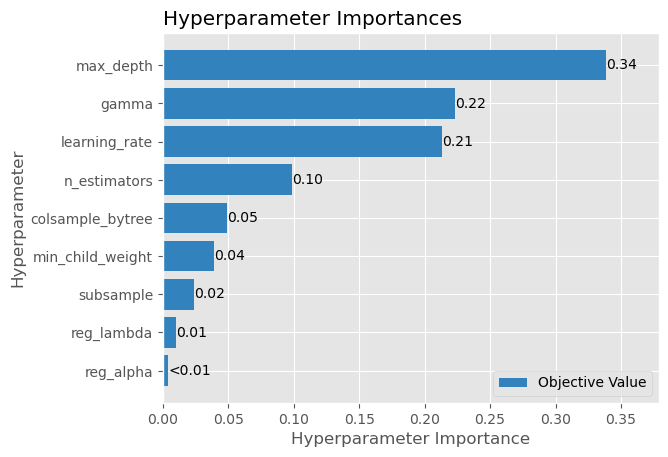

In [89]:
# Parameter importance
optuna.visualization.matplotlib.plot_param_importances(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_21856\2656397370.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study);


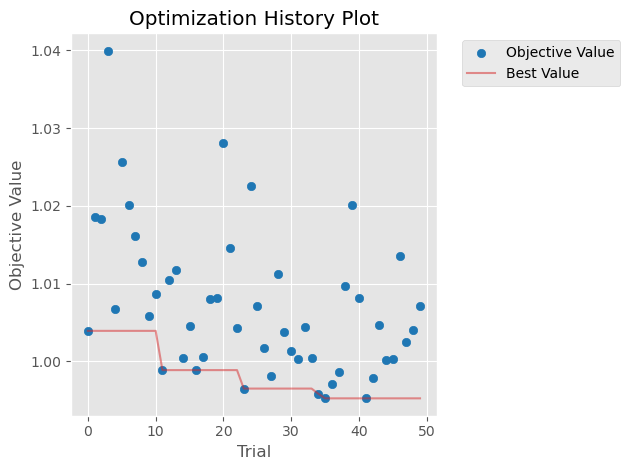

In [90]:
# Optimization history (how F1 improved over trials)
optuna.visualization.matplotlib.plot_optimization_history(study);

C:\Users\Darach\AppData\Local\Temp\ipykernel_21856\2949398106.py:2: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Axes: title={'center': 'Parallel Coordinate Plot'}>

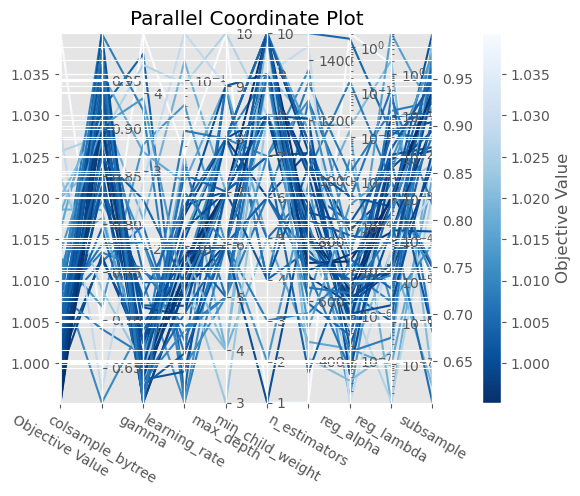

In [91]:
# Parallel coordinate plot (show trade-offs between params and F1)
optuna.visualization.matplotlib.plot_parallel_coordinate(study)

Use best parameters for training on full training data

In [92]:
best_params = {f"model__{k}": v for k, v in best_trial.params.items()}

# Set these in your pipeline
full_pipeline_xgb.set_params(**best_params)

# Fit the pipeline on full training data
full_pipeline_xgb.fit(X_trainval, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Evaluate

In [93]:
# Predict probabilities on training set
train_preds = full_pipeline_xgb.predict(X_trainval)
model_scores.append(score_model('XGB Train', y_trainval, train_preds))

# Predict probabilities on test set
test_preds = full_pipeline_xgb.predict(X_test)
model_scores.append(score_model('XGB Test', y_test, test_preds))

In [94]:
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.79,0.99,193.75,0.037
3,Heuristic Model Test,0.68,0.83,190.62,-0.143
4,XGB Train,0.17,0.23,85.23,0.951
5,XGB Test,0.50,0.63,154.00,0.341
6,XGB reduced Train,0.51,0.64,149.32,0.606
7,XGB reduced Test,0.52,0.64,136.34,0.305
8,XGB Train,0.37,0.48,148.36,0.774
9,XGB Test,0.50,0.63,156.21,0.342


---
Train production model using all data (train and test together) with best params

In [95]:
# clone the pipeline as a production model
pipeline_production = clone(full_pipeline_xgb)
pipeline_production.set_params(**best_params)

# Fit the production pipeline on full data
X_full = df[features].copy()
y_full = df['biodiversity_z']
pipeline_production.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [96]:
# sanity check
X_test = X_test[features]
y_pred = pipeline_production.predict(X_full)

print(r2_score(y_full, y_pred))

0.7538452000287899


save evaluation model and production model

In [97]:
import joblib

joblib.dump({
    "model": full_pipeline_xgb,
    "features": features
}, "../models/evaluation_model_regression.pkl")

joblib.dump({
    "model": pipeline_production,
    "features": features
}, "../models/production_model_regression.pkl")

['../models/production_model_regression.pkl']

---
Train R-squared is quite high and test R-squared is much lower - perhaps overfitting?  
Experiment - can we do better with reduced feature set?

In [74]:
# reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
#  'n_hot_days_lag1', 'n_hot_days_roll3',
#  'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#  'temp_anom_z_lag1', 'temp_anom_z_roll3',
#  'precip_anom_z_lag1', 'precip_anom_z_roll3',
#  'drought_index_lag1','drought_index_roll3', 
#  'log_n_obs', 'biodiversity_z']

reduced_cols = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_roll3',
    'heavy_rain_days_roll3',
    'temp_anom_z', 'temp_anom_z_lag1', 
    'precip_anom_z', 'precip_anom_z_roll3',
    'drought_index', 'drought_index_roll3', 
    'log_n_obs','biodiversity_z']

trainval_reduced = train_val[reduced_cols].copy()
trainval_reduced.columns

Index(['state', 'year_offset', 'month_sin', 'month_cos', 'n_hot_days_roll3',
       'heavy_rain_days_roll3', 'temp_anom_z', 'temp_anom_z_lag1',
       'precip_anom_z', 'precip_anom_z_roll3', 'drought_index',
       'drought_index_roll3', 'log_n_obs', 'biodiversity_z'],
      dtype='object')

In [75]:
num_features_reduced = [c for c in num_features if c in reduced_cols]
num_features_reduced

['year_offset',
 'n_hot_days_roll3',
 'heavy_rain_days_roll3',
 'temp_anom_z',
 'temp_anom_z_lag1',
 'precip_anom_z',
 'precip_anom_z_roll3',
 'drought_index',
 'drought_index_roll3',
 'log_n_obs']

In [76]:
# Create reduced-features pipeline

preprocessor_noscale_reduced = ColumnTransformer(    transformers=[
        ('cat', oh_pipe, cat_features),
        ('num', 'passthrough', num_features_reduced),
        ('cyc', 'passthrough', cyc_features)
    ])


# Rebuild your pipeline with the updated preprocessor

full_pipeline_xgb_reduced = Pipeline([
    ('pre', preprocessor_noscale_reduced),
    ('model', XGBRegressor())
])

In [77]:
# features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
#     'n_hot_days_lag1', 'n_hot_days_roll3',
#     'heavy_rain_days_lag1', 'heavy_rain_days_roll3',
#     'temp_anom_z_lag1', 'temp_anom_z_roll3',
#     'precip_anom_z_lag1', 'precip_anom_z_roll3',
#     'drought_index_lag1', 'drought_index_roll3', 
#     'log_n_obs']

features_reduced = ['state', 'year_offset', 'month_sin', 'month_cos',
    'n_hot_days_roll3',
    'heavy_rain_days_roll3',
    'temp_anom_z', 'temp_anom_z_lag1', 
    'precip_anom_z', 'precip_anom_z_roll3',
    'drought_index', 'drought_index_roll3', 
    'log_n_obs']

study_reduced, results_df_reduced = optuna_rolling_search_regression(
    df=trainval_reduced,
    features=features_reduced,
    target='biodiversity_z',
    pipeline=full_pipeline_xgb_reduced,
    param_space_fn=xgb_param_space,
    n_trials=50
)

[I 2026-04-20 00:08:28,295] A new study created in memory with name: no-name-3d0656e3-da84-4344-9660-9ae8cd9fbf45
[I 2026-04-20 00:08:30,216] Trial 0 finished with value: 1.0055854572046385 and parameters: {'max_depth': 7, 'min_child_weight': 2, 'learning_rate': 0.005495520958439707, 'n_estimators': 200, 'subsample': 0.8068789005075654, 'colsample_bytree': 0.9680987078632766, 'gamma': 2.1225327146119066, 'reg_alpha': 0.30439701329937663, 'reg_lambda': 2.405244411757297e-07}. Best is trial 0 with value: 1.0055854572046385.
[I 2026-04-20 00:08:32,452] Trial 1 finished with value: 1.0340730430940968 and parameters: {'max_depth': 4, 'min_child_weight': 1, 'learning_rate': 0.025208091331172577, 'n_estimators': 729, 'subsample': 0.7963674448261547, 'colsample_bytree': 0.846555936503539, 'gamma': 4.466252369825486, 'reg_alpha': 3.173820554632363e-06, 'reg_lambda': 0.0042271538611014774}. Best is trial 0 with value: 1.0055854572046385.
[I 2026-04-20 00:08:36,934] Trial 2 finished with value: 1

In [78]:
# Sort by F1
results_df_reduced.sort_values('rmse', ascending=True).head(10)

,params,rmse
32,"{'max_depth': 9, 'min_child_weight': 2, 'learn...",1.003074
33,"{'max_depth': 8, 'min_child_weight': 2, 'learn...",1.003409
31,"{'max_depth': 8, 'min_child_weight': 1, 'learn...",1.003995
0,"{'max_depth': 7, 'min_child_weight': 2, 'learn...",1.005585
25,"{'max_depth': 8, 'min_child_weight': 3, 'learn...",1.006324
44,"{'max_depth': 9, 'min_child_weight': 7, 'learn...",1.006325
43,"{'max_depth': 8, 'min_child_weight': 3, 'learn...",1.006683
42,"{'max_depth': 8, 'min_child_weight': 2, 'learn...",1.006895
41,"{'max_depth': 8, 'min_child_weight': 3, 'learn...",1.007038
12,"{'max_depth': 9, 'min_child_weight': 1, 'learn...",1.007825


In [79]:
# Best trial according to Optuna
best_trial_reduced = study_reduced.best_trial

print("Best AUC:", best_trial_reduced.value)
# print("Best threshold_f1:", best_trial_reduced.user_attrs.get('best_threshold_f1', None))
# print("Best threshold_recall:", best_trial_reduced.user_attrs.get('best_threshold_recall', None))
print("Best parameters:")
for key, value in best_trial_reduced.params.items():
    print(f"  {key}: {value}")

Best AUC: 1.003074296919036
Best parameters:
  max_depth: 9
  min_child_weight: 2
  learning_rate: 0.004226813008163088
  n_estimators: 311
  subsample: 0.6691929988626928
  colsample_bytree: 0.9659599714233859
  gamma: 2.5962870163580027
  reg_alpha: 1.1836524834834982e-06
  reg_lambda: 2.336744831398736e-06


Use best parameters for training on full training data with best threshold

In [80]:
best_params_reduced = best_trial_reduced.params
best_params_prefixed = {f"model__{k}": v for k, v in best_params_reduced.items()}

# Set these in pipeline
full_pipeline_xgb_reduced.set_params(**best_params_prefixed)

# Fit the pipeline on full training data
X_trainval_reduced = X_trainval[features_reduced]
full_pipeline_xgb_reduced.fit(X_trainval_reduced, y_trainval)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

Evaluate

In [81]:
# Predict probabilities on training set
train_preds_reduced = full_pipeline_xgb_reduced.predict(X_trainval_reduced)
model_scores.append(score_model('XGB reduced Train', y_trainval, train_preds_reduced))

# Predict probabilities on test set
X_test_reduced = X_test[features_reduced]
test_preds_reduced = full_pipeline_xgb_reduced.predict(X_test_reduced)
model_scores.append(score_model('XGB reduced Test', y_test, test_preds_reduced))

In [82]:
pd.DataFrame(model_scores)

,Model,MAE ($),RMSE ($),MAPE (%),R-Squared
0,Baseline Model Train,0.81,1.01,122.22,0.000
1,Baseline Model Test,0.67,0.81,110.74,-0.105
2,Heuristic Model Train,0.79,0.99,193.75,0.037
3,Heuristic Model Test,0.68,0.83,190.62,-0.143
4,XGB Train,0.17,0.23,85.23,0.951
5,XGB Test,0.50,0.63,154.00,0.341
6,XGB reduced Train,0.51,0.64,149.32,0.606
7,XGB reduced Test,0.52,0.64,136.34,0.305


Slightly better with the reduced feature set

---
Train production model using all data (train and test together) with best params

In [83]:
# clone the pipeline as a production model
pipeline_production = clone(full_pipeline_xgb_reduced)
pipeline_production.set_params(**best_params_prefixed)

# Fit the production pipeline on full data
X_full_reduced = df[features_reduced].copy()
y_full = df['biodiversity_z']
pipeline_production.fit(X_full_reduced, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [84]:
# sanity check
X_test_reduced = X_test[features_reduced]
y_pred = pipeline_production.predict(X_full_reduced)

print(r2_score(y_full, y_pred))

0.5997402739036871


save evaluation model and production model

In [85]:
import joblib

joblib.dump({
    "model": full_pipeline_xgb_reduced,
    "features": features_reduced
}, "../models/evaluation_model_regression_reduced.pkl")

joblib.dump({
    "model": pipeline_production,
    "features": features_reduced
}, "../models/production_model_regression_reduced.pkl")

['../models/production_model_regression_reduced.pkl']